# 05 — Training Loop Demo

End-to-end mini run: self-play games fill a `ReplayBuffer`, then `train_for_n_steps`
optimizes the network on that data with TensorBoard logging. At the end the logged
curves are read back from the event file and plotted inline, so the notebook stays
meaningful without a running TensorBoard server.

Runtime: well under a minute on CPU.

In [1]:
import numpy as np
import torch

from leelax.net.model import LeelaXNet
from leelax.selfplay.worker import SelfPlayWorker
from leelax.selfplay.replay_buffer import ReplayBuffer
from leelax.train.loop import train_for_n_steps
from leelax.train.logger import create_tb_writer

torch.manual_seed(0)
np.random.seed(0)

device = "cpu"
model = LeelaXNet().to(device)

def net_fn(x):
    with torch.no_grad():
        return model(x.to(device))

worker = SelfPlayWorker(net_fn, n_simulations=16, max_moves=60, device=device)
buffer = ReplayBuffer(capacity=50_000)

In [2]:
# generate a small batch of self-play games
for i in range(4):
    samples, moves = worker.play_game(verbose=False)
    buffer.add_many(samples)
    print(f"game {i + 1}: {len(moves)} plies -> buffer size {len(buffer)}")

game 1: 60 plies -> buffer size 60


game 2: 60 plies -> buffer size 120


game 3: 60 plies -> buffer size 180


game 4: 60 plies -> buffer size 240


In [3]:
from datetime import datetime
from pathlib import Path

log_dir = Path("runs") / f"notebook_demo-{datetime.now():%Y%m%d-%H%M%S}"
writer = create_tb_writer(log_dir)

# The dataloader makes one pass over the buffer per call, so we train in small
# "epochs" and let global_step_start keep the logged curves continuous.
global_step = 0
for epoch in range(4):
    global_step = train_for_n_steps(
        model, buffer, steps=30,
        batch_size=8, lr=1e-3, device=device,
        tb_writer=writer, global_step_start=global_step,
    )
    print(f"epoch {epoch + 1}: global_step = {global_step}")

writer.close()

epoch 1: global_step = 30


epoch 2: global_step = 60


epoch 3: global_step = 90


epoch 4: global_step = 120


Read the logged scalars back from the event file and plot them inline
(`make tb` starts the interactive TensorBoard UI on the same `runs/` directory).

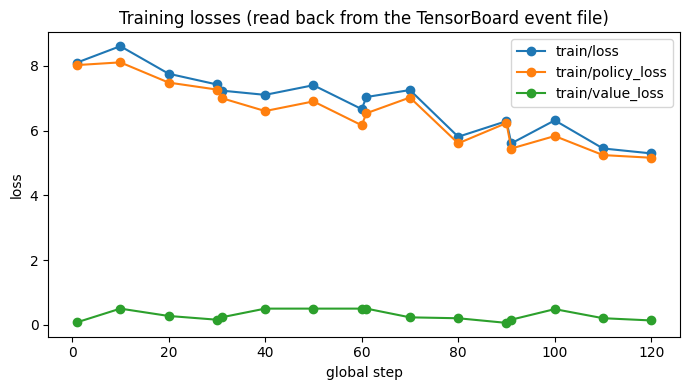

In [4]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

acc = EventAccumulator(str(log_dir))
acc.Reload()

fig, ax = plt.subplots(figsize=(7, 4))
for tag in ["train/loss", "train/policy_loss", "train/value_loss"]:
    events = acc.Scalars(tag)
    ax.plot([e.step for e in events], [e.value for e in events], marker="o", label=tag)
ax.set_xlabel("global step")
ax.set_ylabel("loss")
ax.set_title("Training losses (read back from the TensorBoard event file)")
ax.legend()
plt.tight_layout()
plt.show()